# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Завантажуємо дані
df = pd.read_csv('../data/House_Rent_Dataset.csv', sep=None, engine='python')

# Перше знайомство з даними
df.shape

(4746, 12)

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [5]:
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_percent

Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64

In [6]:
df.describe().round(2)

,BHK,Rent,Size,Bathroom
count,4746.00,4746.00,4746.00,4746.00
mean,2.08,34993.45,967.49,1.97
std,0.83,78106.41,634.20,0.88
min,1.00,1200.00,10.00,1.00
25%,2.00,10000.00,550.00,1.00
50%,2.00,16000.00,850.00,2.00
75%,3.00,33000.00,1200.00,2.00
max,6.00,3500000.00,8000.00,10.00


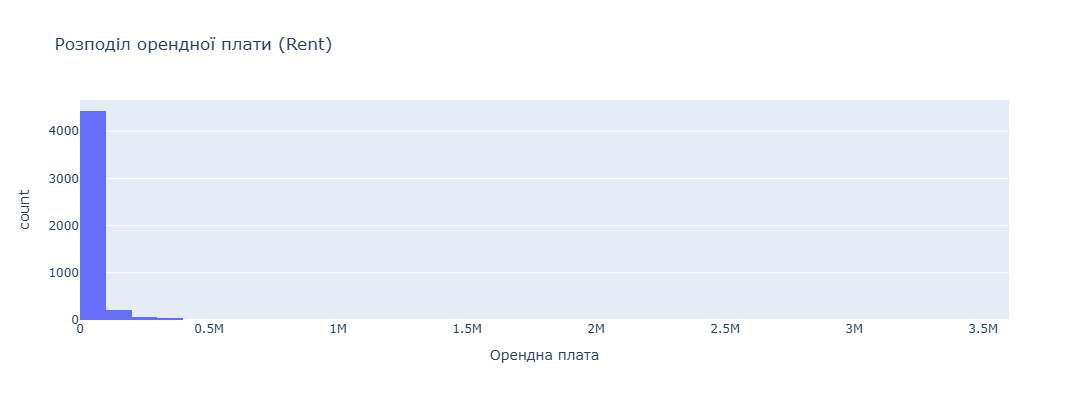

In [7]:
fig = px.histogram(
    df,
    x='Rent',
    nbins=50,
    title='Розподіл орендної плати (Rent)',
    labels={'Rent': 'Орендна плата', 'count': 'Кількість оголошень'}
)

fig.update_layout(
    showlegend=False,
    height=400
)

fig.show()

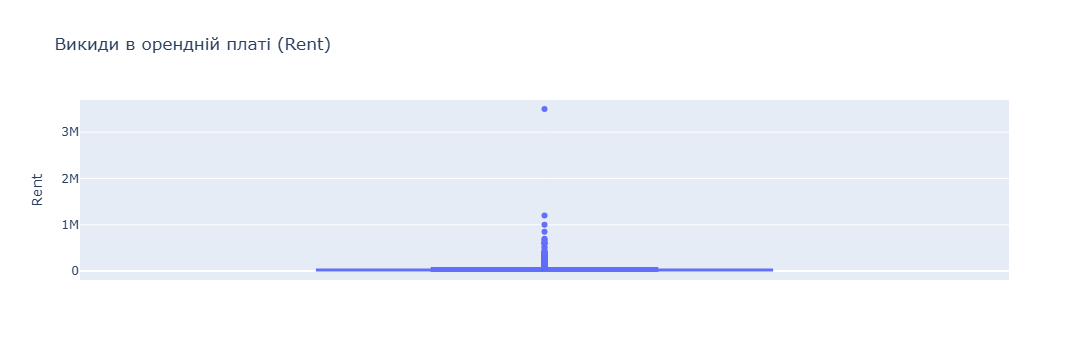

In [8]:
fig = px.box(
    df,
    y='Rent',
    title='Викиди в орендній платі (Rent)'
)

fig.show()

In [9]:
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Rent'] < lower_bound) | (df['Rent'] > upper_bound)]
print("Кількість викидів:", len(outliers))

df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]

Кількість викидів: 520


In [10]:
df_clean.shape

(4226, 12)

In [11]:
cat_cols = df.select_dtypes(include='object').columns

df[cat_cols].nunique()

Posted On              81
Floor                 480
Area Type               3
Area Locality        2235
City                    6
Furnishing Status       3
Tenant Preferred        3
Point of Contact        3
dtype: int64


## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [12]:
metrics_df = df_clean.select_dtypes(include=['int64', 'float64'])

correlation_matrix = metrics_df.corr()

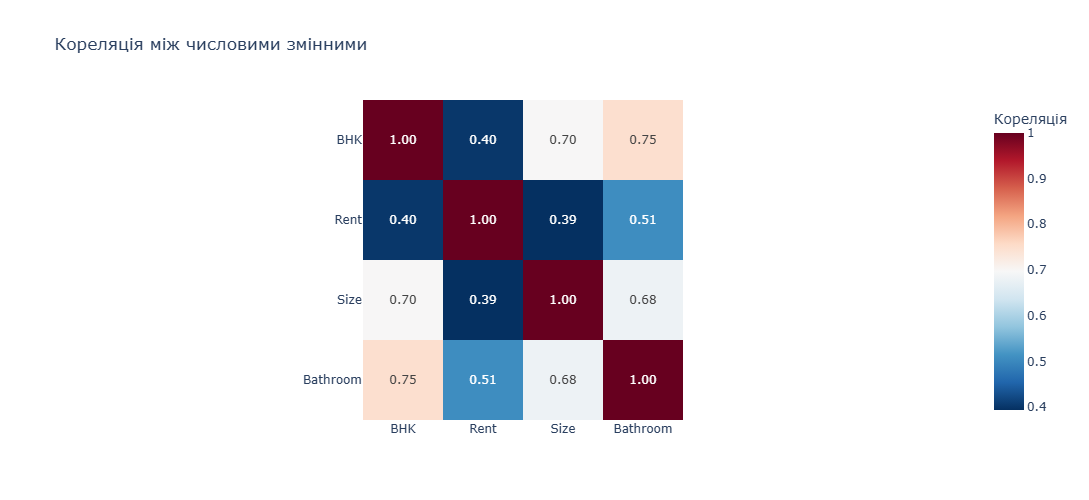

In [13]:
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між числовими змінними',
    labels=dict(color="Кореляція")
)

fig.update_layout(height=500)
fig.show()

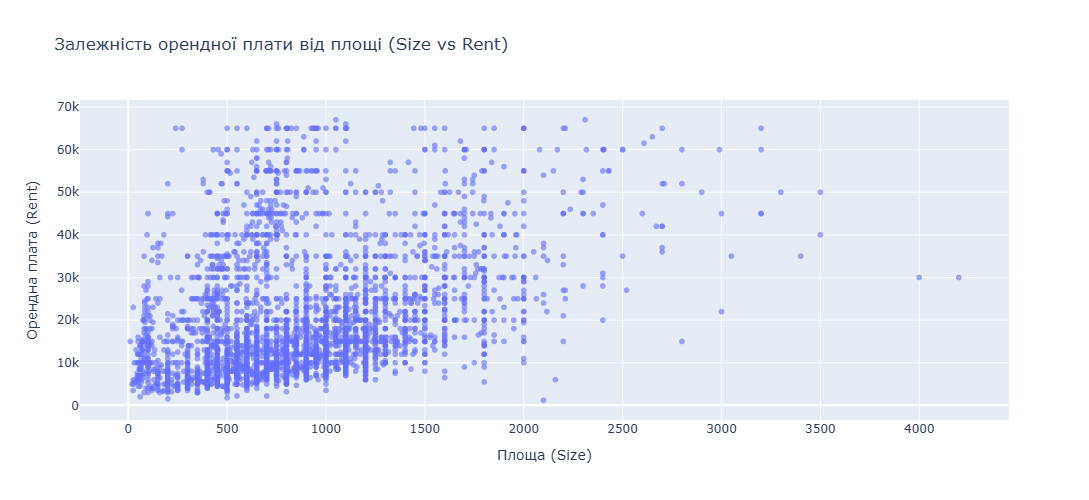

In [14]:
fig = px.scatter(
    df_clean,
    x='Size',
    y='Rent',
    title='Залежність орендної плати від площі (Size vs Rent)',
    labels={
        'Size': 'Площа (Size)',
        'Rent': 'Орендна плата (Rent)'
    },
    opacity=0.6
)

fig.update_layout(height=500)
fig.show()

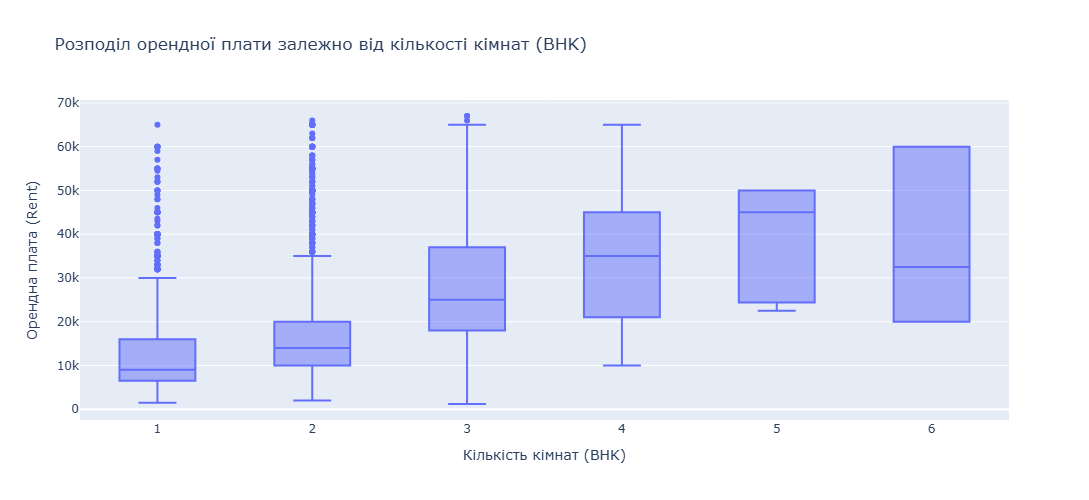

In [15]:
fig = px.box(
    df_clean,
    x='BHK',
    y='Rent',
    title='Розподіл орендної плати залежно від кількості кімнат (BHK)',
    labels={
        'BHK': 'Кількість кімнат (BHK)',
        'Rent': 'Орендна плата (Rent)'
    }
)

fig.update_layout(height=500)
fig.show()

За допомогою boxplot видно, що чим більше кімнат у квартирі (BHK), тим зазвичай вища орендна плата. У більших квартирах також спостерігається більший розкид цін - є як дешевші, так і значно дорожчі варіанти. На графіку помітні окремі незвичайні значення (викиди), особливо для 1-2-кімнатних квартир, що може свідчити про дуже дорогі або навпаки дешеві об’єкти. Загалом можна зробити висновок, що BHK є важливим фактором, який впливає на формування орендної плати.

## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [16]:
df_model = df_clean.copy()

In [17]:
small_cat_cols = ['Furnishing Status', 'Tenant Preferred', 'Point of Contact']

dummies = pd.get_dummies(
    df_model[small_cat_cols],
    drop_first=True
).astype(int)

df_model = pd.concat([df_model, dummies], axis=1)

In [18]:
top_cities = df_model['City'].value_counts().head(5).index

df_model['City_grouped'] = df_model['City'].apply(
    lambda x: x if x in top_cities else 'other'
)

city_dummies = pd.get_dummies(
    df_model['City_grouped'],
    prefix='City',
    drop_first=True
).astype(int)

df_model = pd.concat([df_model, city_dummies], axis=1)

In [19]:
df_model.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact', 'Furnishing Status_Semi-Furnished',
       'Furnishing Status_Unfurnished', 'Tenant Preferred_Bachelors/Family',
       'Tenant Preferred_Family', 'Point of Contact_Contact Builder',
       'Point of Contact_Contact Owner', 'City_grouped', 'City_Chennai',
       'City_Delhi', 'City_Hyderabad', 'City_Mumbai', 'City_other'],
      dtype='object')

In [20]:
df_model['price_per_sqft'] = df_model['Rent'] / df_model['Size']
df_model['rooms_per_bathroom'] = df_model['BHK'] / df_model['Bathroom']

In [21]:
df_model = df_model.drop(columns=[
    'Posted On',
    'Floor',
    'Area Type',
    'Area Locality',
    'City',
    'Furnishing Status',
    'Tenant Preferred',
    'Point of Contact',
    'City_grouped'
])

In [22]:
features = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
features.remove('Rent')

X = df_model[features]
y = df_model['Rent']

print(f"Розмір X: {X.shape}")
print(f"Розмір y: {y.shape}")

Розмір X: (4226, 16)
Розмір y: (4226,)


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled_df.head()

,BHK,Size,Bathroom,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Builder,Point of Contact_Contact Owner,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_other,price_per_sqft,rooms_per_bathroom
0,0.052966,0.469859,0.272578,-0.940704,1.205870,0.597576,-0.315692,-0.015385,0.577897,-0.501774,-0.387614,-0.499926,-0.408755,2.660884,-0.469635,-0.358513
1,0.052966,-0.147778,-1.133910,1.063034,-0.829277,0.597576,-0.315692,-0.015385,0.577897,-0.501774,-0.387614,-0.499926,-0.408755,2.660884,-0.126157,2.242635
2,0.052966,0.263980,-1.133910,1.063034,-0.829277,0.597576,-0.315692,-0.015385,0.577897,-0.501774,-0.387614,-0.499926,-0.408755,2.660884,-0.298878,2.242635
3,0.052966,-0.147778,-1.133910,-0.940704,1.205870,0.597576,-0.315692,-0.015385,0.577897,-0.501774,-0.387614,-0.499926,-0.408755,2.660884,-0.396033,2.242635
4,0.052966,-0.044839,-1.133910,-0.940704,1.205870,-1.673428,-0.315692,-0.015385,0.577897,-0.501774,-0.387614,-0.499926,-0.408755,2.660884,-0.475408,2.242635


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [27]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [28]:
for feature, weight in zip(model.feature_names_in_, model.coef_):
    print(f"{feature}: {weight:.2f}")

print(f"\nЗміщення (intercept): {model.intercept_:.2f}")

BHK: 2544.64
Size: 6382.27
Bathroom: 72.81
Furnishing Status_Semi-Furnished: -1506.77
Furnishing Status_Unfurnished: -1830.10
Tenant Preferred_Bachelors/Family: -267.98
Tenant Preferred_Family: -536.38
Point of Contact_Contact Builder: -62.26
Point of Contact_Contact Owner: -3481.21
City_Chennai: -379.43
City_Delhi: -243.36
City_Hyderabad: -1176.34
City_Mumbai: 5643.11
City_other: -827.44
price_per_sqft: 4500.70
rooms_per_bathroom: -686.10

Зміщення (intercept): 19339.88


Найбільший вплив на прогноз орендної плати мають ознаки Size та City_Mumbai, оскільки вони мають найбільші коефіцієнти за модулем у моделі.

In [29]:
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Реальна орендна плата': y_test.values[:10],
    'Прогнозована орендна плата': y_test_pred[:10].round(0),
    'Помилка': (y_test.values[:10] - y_test_pred[:10]).round(0)
})

print("Приклади прогнозів на тестовій вибірці:")
print(comparison)

Приклади прогнозів на тестовій вибірці:
   Реальна орендна плата  Прогнозована орендна плата  Помилка
0                  22000                     28752.0  -6752.0
1                   5000                      2902.0   2098.0
2                  37000                     38555.0  -1555.0
3                   8000                      2561.0   5439.0
4                  15000                     14918.0     82.0
5                  20000                     21263.0  -1263.0
6                   8500                     14512.0  -6012.0
7                   7000                      4518.0   2482.0
8                   3000                      -566.0   3566.0
9                   8000                      4851.0   3149.0


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (тестова вибірка):")
print("="*50)
print(f"MAE: {test_mae:.2f} індійських рупій")
print(f"RMSE: {test_rmse:.2f} індійських рупій")
print(f"R²: {test_r2:.3f}")

train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print("="*50)
print("МЕТРИКИ ЯКОСТІ МОДЕЛІ (навчальна вибірка):")
print("="*50)
print(f"MAE: {train_mae:.2f} індійських рупій")
print(f"RMSE: {train_rmse:.2f} індійських рупій")
print(f"R²: {train_r2:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ (тестова вибірка):
MAE: 5119.41 індійських рупій
RMSE: 8426.95 індійських рупій
R²: 0.630
МЕТРИКИ ЯКОСТІ МОДЕЛІ (навчальна вибірка):
MAE: 5061.58 індійських рупій
RMSE: 7052.93 індійських рупій
R²: 0.739


Модель показує кращі результати на навчальній вибірці (R² = 0.739), ніж на тестовій (R² = 0.630), однак різниця між ними є невеликою. Це означає, що модель узагальнює дані достатньо добре. Значення R² на тестовій вибірці свідчить, що модель пояснює близько 63% варіації орендної плати, що є непоганим результатом для лінійної регресії.

Ознак сильного перенавчання не спостерігається, оскільки різниця між метриками на навчальній та тестовій вибірках не є великою. Водночас модель не є ідеальною, що може свідчити про наявність інших факторів, які не враховані в моделі.

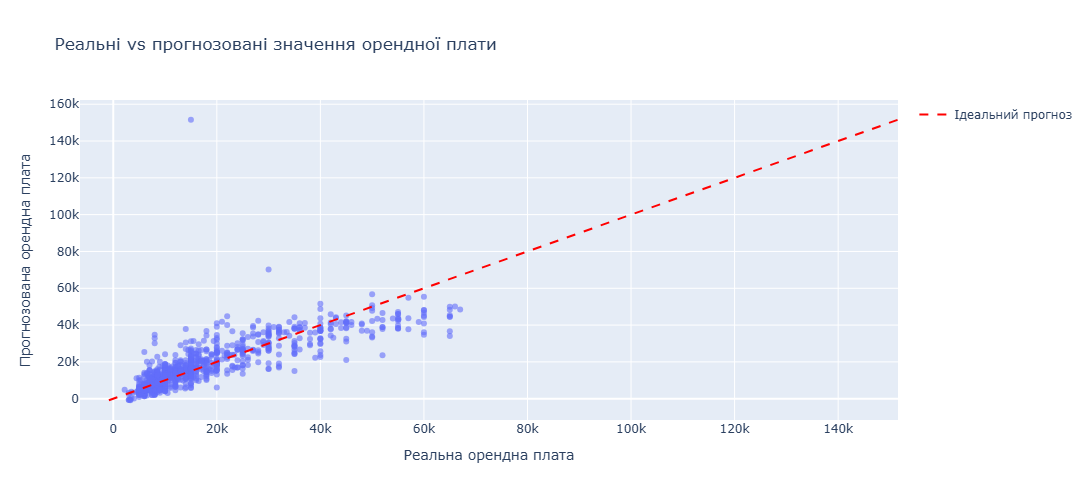

In [31]:
fig = px.scatter(
    x=y_test,
    y=y_test_pred,
    title='Реальні vs прогнозовані значення орендної плати',
    labels={
        'x': 'Реальна орендна плата',
        'y': 'Прогнозована орендна плата'
    },
    opacity=0.6
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        name='Ідеальний прогноз',
        line=dict(color='red', dash='dash')
    )
)

fig.update_layout(height=500)
fig.show()

На графіку видно, що більшість прогнозів знаходяться близько до ідеальної лінії, що свідчить про достатньо хорошу якість моделі. Але є розкид значень, особливо для дорогих квартир - їх модель часто оцінює нижче, ніж є насправді. Тобто модель добре показує загальну тенденцію, але не завжди точно передбачає високі ціни.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

In [32]:
residuals = y_test - y_test_pred

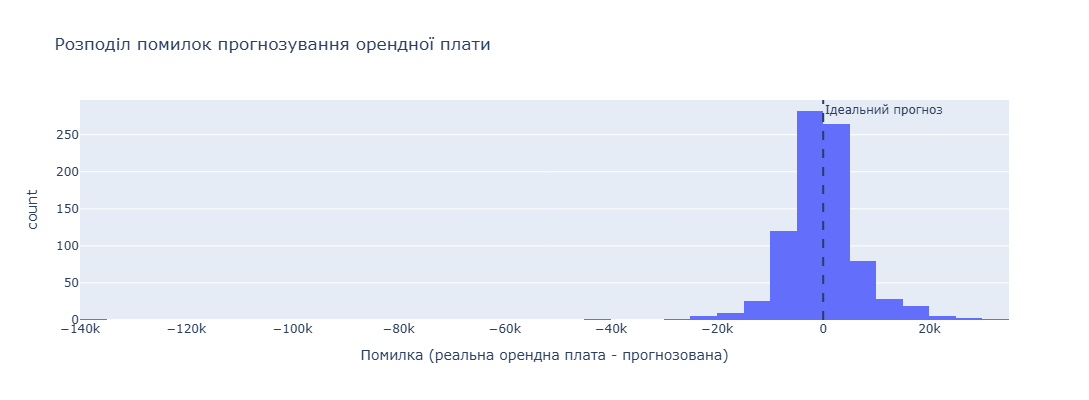

In [33]:
fig = px.histogram(
    x=residuals,
    nbins=50,
    title='Розподіл помилок прогнозування орендної плати',
    labels={
        'x': 'Помилка (реальна орендна плата - прогнозована)',
        'count': 'Кількість оголошень'
    }
)

fig.add_vline(
    x=0,
    line_dash="dash",
    annotation_text="Ідеальний прогноз"
)

fig.update_layout(height=400)
fig.show()

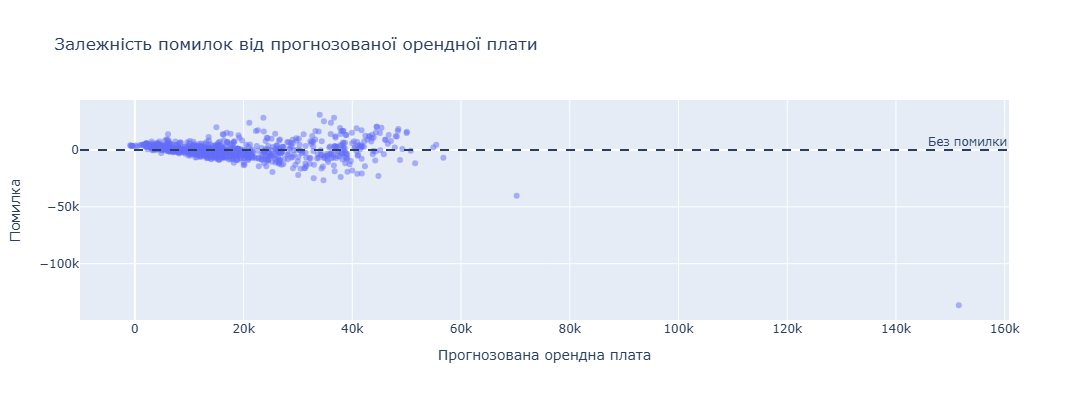

In [34]:
fig = px.scatter(
    x=y_test_pred,
    y=residuals,
    title='Залежність помилок від прогнозованої орендної плати',
    labels={
        'x': 'Прогнозована орендна плата',
        'y': 'Помилка'
    },
    opacity=0.5
)

fig.add_hline(
    y=0,
    line_dash="dash",
    annotation_text="Без помилки"
)

fig.update_layout(height=400)
fig.show()

На графіку видно, що зі збільшенням прогнозованої орендної плати розкид помилок зростає. Це означає, що модель гірше працює для дорогих об’єктів і допускає більші помилки при високих значеннях. Для дешевших квартир прогноз є більш точним.

In [35]:
errors_df = pd.DataFrame({
    'real_rent': y_test.values,
    'predicted_rent': y_test_pred,
    'residual': residuals.values,
    'absolute_error': np.abs(residuals.values)
}, index=y_test.index)

errors_df = errors_df.join(df_clean[['BHK', 'City', 'Size', 'Bathroom']], how='left')

top_errors = errors_df.nlargest(5, 'absolute_error')

print("ТОП-5 найбільших помилок:")
top_errors

ТОП-5 найбільших помилок:


,real_rent,predicted_rent,residual,absolute_error,BHK,City,Size,Bathroom
4653,15000,151557.794689,-136557.794689,136557.794689,3,Hyderabad,10,3
275,30000,70238.641035,-40238.641035,40238.641035,4,Kolkata,4000,3
3962,65000,34002.169870,30997.830130,30997.830130,3,Hyderabad,1850,3
3520,65000,36638.456513,28361.543487,28361.543487,3,Chennai,1444,3
2512,52000,23650.526024,28349.473976,28349.473976,2,Delhi,1125,2


In [36]:
errors_by_bhk = errors_df.groupby('BHK')['absolute_error'].mean().sort_values(ascending=False)

print("Помилка за кількістю кімнат:")
print(errors_by_bhk)

Помилка за кількістю кімнат:
BHK
4    10361.980543
6     9731.901627
3     7953.413764
5     6749.662942
2     4412.099695
1     4170.949212
Name: absolute_error, dtype: float64


In [37]:
errors_by_city = errors_df.groupby('City')['absolute_error'].mean().sort_values(ascending=False)

print("\nПомилка за містами:")
print(errors_by_city.head(10))


Помилка за містами:
City
Mumbai       8054.209722
Delhi        6029.874192
Hyderabad    5520.392317
Chennai      4314.113537
Kolkata      4016.123883
Bangalore    3639.632402
Name: absolute_error, dtype: float64


Модель найбільше помиляється для квартир з великою кількістю кімнат (3 і більше), а також для житла у великих містах, таких як Mumbai та Delhi. Це свідчить про те, що модель гірше прогнозує дорогі та більш складні об’єкти. Для невеликих квартир помилки є значно меншими, що означає кращу точність моделі в цьому сегменті.

Для покращення якості моделі можна спробувати декілька варіантів:

1) Додати нові ознаки, які краще описують характеристики житла, наприклад, більш детальну інформацію про локацію.

2) Використати більш складні моделі (Decision Tree, наприклад), які краще працюють з нелінійними залежностями.

3) Обробити викиди або трансформувати дані, щоб зменшити вплив дуже великих значень, що допоможе моделі точніше прогнозувати дорогі об’єкти.